<a href="https://colab.research.google.com/github/rafaysiddiquie37/sbp-remittance-forecasting/blob/main/SBP_Remittance_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SBP Remittance Forecasting Model
**Author:** Muhammad Rafay Siddiquie  
**Tool:** Python (Google Colab)  
**Model:** Random Forest Regressor  

This project predicts Pakistan's workers' remittance inflows using macroeconomic indicators from the State Bank of Pakistan (SBP) dataset. Key techniques include log-transformation of the target variable, label encoding of categorical features, and feature importance analysis.

**Final R² Score: 0.9861**

## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

## 2. Load Dataset

In [4]:
df = pd.read_csv('SBP Remittance dataset.csv')
print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (21861, 18)


/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Dataset Name,Observation Date,Series Key,Series Display Name,Observation Value,Unit,Observation Status,Series name,Gold,USD Rate parity,Silver,Crude Oil,S&P 500,USD Interest Rate,Total Popuation,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,Country-wise Workers' Remittances,30-Sep-25,TS_GP_BOP_WR_M.WR0010,I. Cash Flow,3183.749768,Million USD,Normal,Total Cash inflow of Workers' remittances in P...,2983.25,0.003551,39.02,63.39,6688.46,4.33,200.7,NaN,NaN,NaN
1,Country-wise Workers' Remittances,30-Sep-25,TS_GP_BOP_WR_M.WR0020,......1 USA,269.026519,Million USD,Normal,Workers' remittances received from U.S.A.,2983.25,0.003551,39.02,63.39,6688.46,4.33,200.7,NaN,NaN,NaN
2,Country-wise Workers' Remittances,30-Sep-25,TS_GP_BOP_WR_M.WR0030,......2 U.K.,454.804585,Million USD,Normal,Workers' remittances received from U.K.,2983.25,0.003551,39.02,63.39,6688.46,4.33,200.7,NaN,NaN,NaN
3,Country-wise Workers' Remittances,30-Sep-25,TS_GP_BOP_WR_M.WR0040,......3 Saudi Arabia,750.904484,Million USD,Normal,Workers' remittances received from Saudi Arabia,2983.25,0.003551,39.02,63.39,6688.46,4.33,200.7,NaN,NaN,NaN
4,Country-wise Workers' Remittances,30-Sep-25,TS_GP_BOP_WR_M.WR0050,......4 U.A.E.,677.139199,Million USD,Normal,Workers' remittances received from U.A.E.,2983.25,0.003551,39.02,63.39,6688.46,4.33,200.7,NaN,NaN,NaN


## 3. Data Cleaning

In [5]:
# Drop irrelevant columns
df = df.drop(columns=[
    'Dataset Name', 'Series Key', 'Unit',
    'Observation Status', 'Series name',
])

# Drop unnamed/empty columns
df = df.drop(columns=[c for c in df.columns if 'Unnamed' in c])

# Convert date and extract time features
df['Observation Date'] = pd.to_datetime(df['Observation Date'], dayfirst=True, errors='coerce')
df['Year']    = df['Observation Date'].dt.year
df['Month']   = df['Observation Date'].dt.month
df['Quarter'] = df['Observation Date'].dt.quarter
df = df.drop(columns=['Observation Date'])

# Remove missing values
df = df.dropna()

print('Shape after cleaning:', df.shape)
df.head()

Shape after cleaning: (12234, 12)


/tmp/ipykernel_24859/1521676780.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Observation Date'] = pd.to_datetime(df['Observation Date'], dayfirst=True, errors='coerce')


,Series Display Name,Observation Value,Gold,USD Rate parity,Silver,Crude Oil,S&P 500,USD Interest Rate,Total Popuation,Year,Month,Quarter
0,I. Cash Flow,3183.749768,2983.25,0.003551,39.02,63.39,6688.46,4.33,200.7,2025,9,3
1,......1 USA,269.026519,2983.25,0.003551,39.02,63.39,6688.46,4.33,200.7,2025,9,3
2,......2 U.K.,454.804585,2983.25,0.003551,39.02,63.39,6688.46,4.33,200.7,2025,9,3
3,......3 Saudi Arabia,750.904484,2983.25,0.003551,39.02,63.39,6688.46,4.33,200.7,2025,9,3
4,......4 U.A.E.,677.139199,2983.25,0.003551,39.02,63.39,6688.46,4.33,200.7,2025,9,3


## 4. Feature Engineering

In [6]:
# Encode Series Display Name (country/category of remittance)
le = LabelEncoder()
df['Series_Code'] = le.fit_transform(df['Series Display Name'])
df = df.drop(columns=['Series Display Name'])

# Log-transform target to handle skewed distribution
df['Log_Target'] = np.log1p(df['Observation Value'])

print('Target distribution before log transform:')
print(df['Observation Value'].describe())
print('\nTarget distribution after log transform:')
print(df['Log_Target'].describe())

Target distribution before log transform:
count    12234.000000
mean       110.109329
std        350.359727
min          0.000000
25%          1.100000
50%          7.700000
75%         56.100000
max       4053.579523
Name: Observation Value, dtype: float64

Target distribution after log transform:
count    12234.000000
mean         2.558351
std          2.014843
min          0.000000
25%          0.741937
50%          2.163323
75%          4.044804
max          8.307602
Name: Log_Target, dtype: float64


## 5. Feature Selection & Train-Test Split

In [7]:
X = df.drop(columns=['Observation Value', 'Log_Target'])
y = df['Log_Target']
y_actual = df['Observation Value']

X_train, X_test, y_train, y_test, _, y_test_actual = train_test_split(
    X, y, y_actual, test_size=0.20, random_state=42
)

print('Training samples:', X_train.shape[0])
print('Testing samples :', X_test.shape[0])
print('Features        :', X.columns.tolist())

Training samples: 9787
Testing samples : 2447
Features        : ['Gold', 'USD Rate parity', 'Silver ', 'Crude Oil', 'S&P 500', 'USD Interest Rate', 'Total Popuation ', 'Year', 'Month', 'Quarter', 'Series_Code']


## 6. Train Random Forest Model

In [8]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print('Model training complete.')

Model training complete.


## 7. Prediction & Evaluation

In [9]:
y_pred_log = rf_model.predict(X_test)
y_pred = np.expm1(y_pred_log)  # Reverse log transform

mse = mean_squared_error(y_test_actual, y_pred)
r2  = r2_score(y_test_actual, y_pred)

print('=== Model Performance ===')
print(f'Mean Squared Error : {mse:,.2f}')
print(f'R\u00b2 Score           : {r2:.4f}')

=== Model Performance ===
Mean Squared Error : 1,808.95
R² Score           : 0.9860


## 8. Feature Importance

=== Feature Importance ===
          Feature  Importance
      Series_Code    0.757944
 Total Popuation     0.139311
             Gold    0.046848
  USD Rate parity    0.032674
          S&P 500    0.008724
          Silver     0.007982
USD Interest Rate    0.002112
        Crude Oil    0.001930
             Year    0.001847
            Month    0.000520
          Quarter    0.000108


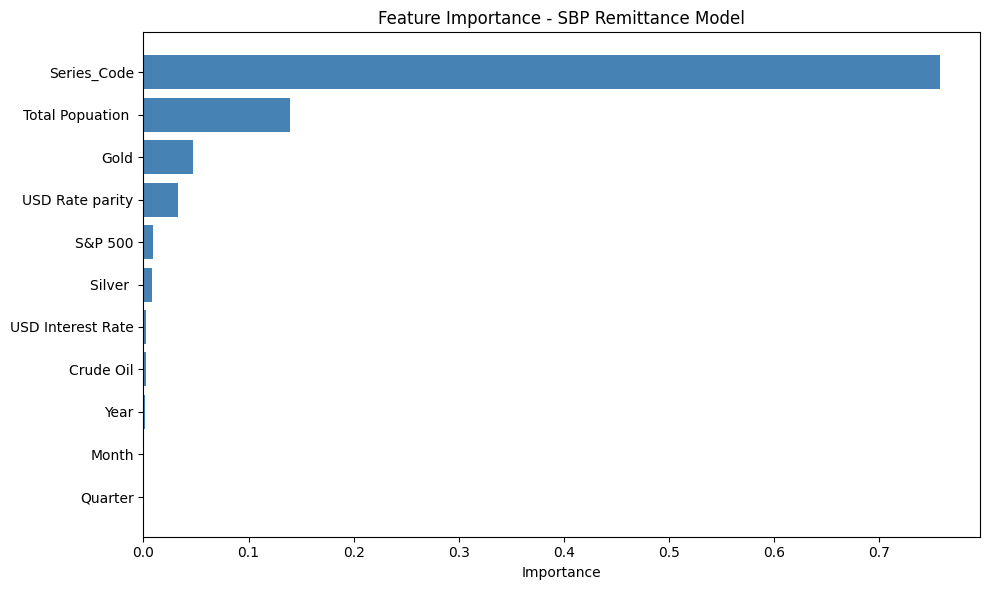

In [10]:
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print('=== Feature Importance ===')
print(feature_importance.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance - SBP Remittance Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()